# Non-Stationary Thresholds: Quantile Regression → GPD

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/evt_quantile_regression_gpd.ipynb)

The previous POT notebook used a *constant* threshold $u$. That is fine for stationary data but breaks down whenever the location of the distribution drifts in time — a warming climate, an aging asset, a covariate-driven trend. Using a constant threshold then produces too few exceedances early on and far too many late on, biasing both the rate $\lambda_u$ and the GPD scale.

This notebook introduces the **quantile-regression threshold** — fit a $\tau$-quantile of the data as a function of time and/or covariates via linear programming, then run a stationary GPD on the residual exceedances. It is a clean and pragmatic split: the *threshold* absorbs the non-stationary mean structure, the *GPD* models the residual tail.

**What we cover**

1. **Theory.** Quantile regression as the LP that minimises the asymmetric pinball loss; what it estimates and what it does not.
2. **A trended series.** Synthetic 80-year daily process with a slow upward trend and seasonal cycle.
3. **Constant vs trend threshold.** Side-by-side fits of `quantile_threshold` (constant) and `quantile_regression_threshold` (linear-in-time); compare the rates of exceedances per decade.
4. **GPD on residual exceedances.** Same NumPyro fit as the previous notebook, applied to $y_i = z_i - u(t_i)$.
5. **Time-varying return levels.** With a non-stationary threshold, the year-$T$ return level is also time-varying.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xtremax[threshold] @ git+https://github.com/jejjohnson/xtremax@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as ndist
import pandas as pd
import xarray as xr
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax.distributions import GeneralizedParetoDistribution
from xtremax.extraction import (
    decluster_runs,
    quantile_regression_threshold,
    quantile_threshold,
)


KEY = jax.random.PRNGKey(0)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,numpy,matplotlib,numpyro,xarray,scikit-learn,xtremax",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax         : 0.6.2
numpy       : 2.4.4
matplotlib  : 3.10.8
numpyro     : 0.19.0
xarray      : 2026.4.0
scikit-learn: 1.8.0
xtremax     : 0.0.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. Quantile regression in one screen

Classical OLS regression solves

$$
\hat\beta_{\text{OLS}} \;=\; \arg\min_\beta \sum_{i} (y_i - x_i^\top \beta)^2.
$$

For a target quantile $\tau \in (0, 1)$, **quantile regression** (Koenker & Bassett, 1978) replaces the squared loss with the *asymmetric pinball loss*

$$
\rho_\tau(r) \;=\; r \cdot \bigl(\tau - \mathbf{1}_{r < 0}\bigr) \;=\;
\begin{cases} \tau\, r, & r \ge 0,\\ -(1-\tau)\, r, & r < 0,\end{cases}
$$

and solves

$$
\hat\beta_\tau \;=\; \arg\min_\beta \sum_{i} \rho_\tau(y_i - x_i^\top \beta).
$$

This is a *linear program* (the pinball loss is piecewise linear), efficiently solved by HiGHS or any LP backend. The result is a hyperplane $x^\top \hat\beta_\tau$ that estimates the conditional quantile $Q_\tau(Y \mid X=x)$.

**What it estimates.** $Q_\tau(Y \mid X)$ — the $\tau$-th conditional quantile of $Y$ given the features. With features $X = (1, t)$ this is a linear-in-time quantile; with $X = (1, t, z_t)$ a covariate-adjusted quantile.

**What it does *not* estimate.** It says nothing about *what is above the line* — the tail behaviour, the rate of exceedances, the heaviness of excess events. That is the GPD's job in the next step.

**Why $\tau \approx 0.95$ is the right choice for POT.** We want the threshold $u(t)$ to track a fixed *upper percentile* of the data so that the rate of exceedances $\lambda_{u(t)} = \mathbb{P}(X_t > u(t))$ is approximately constant across time — exactly $1 - \tau$ of the days. With a constant threshold under non-stationary data, $\lambda_u$ drifts with the trend, and the Poisson-GPD return-level formula loses its meaning.

## 2. Synthetic trended daily series

We simulate a daily process with a *clear upward trend* (think: warming climate, sensor drift), a seasonal cycle, and Gaussian noise. The fixed-quantile threshold should bend with the trend; a constant threshold cannot.

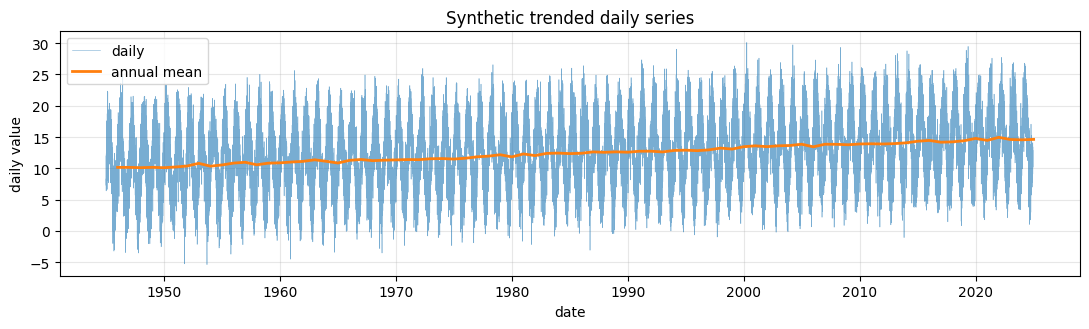

In [4]:
N_YEARS = 80
DAYS_PER_YEAR = 365
RNG = np.random.default_rng(20260429)

dates = pd.date_range("1945-01-01", periods=N_YEARS * DAYS_PER_YEAR, freq="D")
n = N_YEARS * DAYS_PER_YEAR
day_of_year = (dates.dayofyear - 1).to_numpy()
year_index = np.arange(n) / DAYS_PER_YEAR

trend = 0.06 * year_index  # ~ 4.8 over 80 years
seasonal = 6.0 * np.sin(2 * np.pi * day_of_year / DAYS_PER_YEAR)
noise = RNG.normal(0.0, 3.0, size=n)
daily = 10.0 + trend + seasonal + noise

series = xr.DataArray(daily, dims="time", coords={"time": dates})

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(series.time, series.values, lw=0.4, alpha=0.6, color="tab:blue", label="daily")
yearly_mean = series.resample(time="YE").mean()
ax.plot(
    yearly_mean.time, yearly_mean.values, lw=2, color="tab:orange", label="annual mean"
)
ax.set_title("Synthetic trended daily series")
ax.set_xlabel("date")
ax.set_ylabel("daily value")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Constant vs quantile-regression threshold

We fit two thresholds: a constant 95th-percentile via `quantile_threshold` and a linear-trend 95th-percentile via `quantile_regression_threshold`. The latter solves the LP

$$
(\hat\beta_0, \hat\beta_1) \;=\; \arg\min_{\beta_0, \beta_1} \sum_{i} \rho_{0.95}\bigl(z_i - \beta_0 - \beta_1 t_i\bigr).
$$

`xtremax.extraction.quantile_regression_threshold` is `[threshold]`-extra functionality that wraps `sklearn.linear_model.QuantileRegressor`.

Constant 95th-percentile threshold: 21.038
Quantile-regression endpoints:      18.282 → 23.109  (slope ≈ 0.0603/yr)


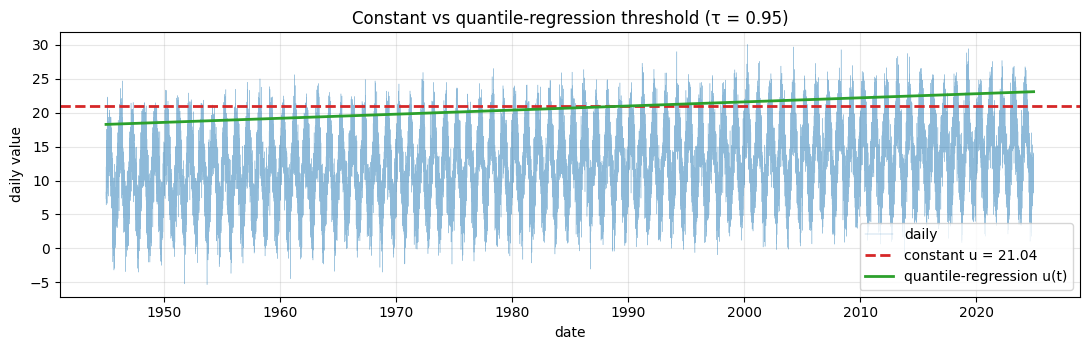

In [5]:
TARGET_TAU = 0.95
u_const = float(quantile_threshold(series, TARGET_TAU))
u_qr = quantile_regression_threshold(series, quantile=TARGET_TAU, time_dim="time")

print(f"Constant 95th-percentile threshold: {u_const:.3f}")
print(
    f"Quantile-regression endpoints:      "
    f"{float(u_qr.values[0]):.3f} → {float(u_qr.values[-1]):.3f}  "
    f"(slope ≈ {(float(u_qr.values[-1]) - float(u_qr.values[0])) / N_YEARS:.4f}/yr)"
)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(series.time, series.values, lw=0.3, alpha=0.5, color="tab:blue", label="daily")
ax.axhline(u_const, color="tab:red", lw=2, ls="--", label=f"constant u = {u_const:.2f}")
ax.plot(
    u_qr.time, u_qr.values, color="tab:green", lw=2, label="quantile-regression u(t)"
)
ax.set_xlabel("date")
ax.set_ylabel("daily value")
ax.set_title("Constant vs quantile-regression threshold (τ = 0.95)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Per-decade exceedance rates

This plot quantifies the bias. With a constant threshold, the trend pushes more and more daily values above $u$ over time — by year 80, the 95th percentile is well below the bulk of the daily values, and the "exceedance rate" $\lambda_u$ has drifted from a few percent to tens of percent. The quantile-regression threshold tracks the trend and keeps the rate stable.

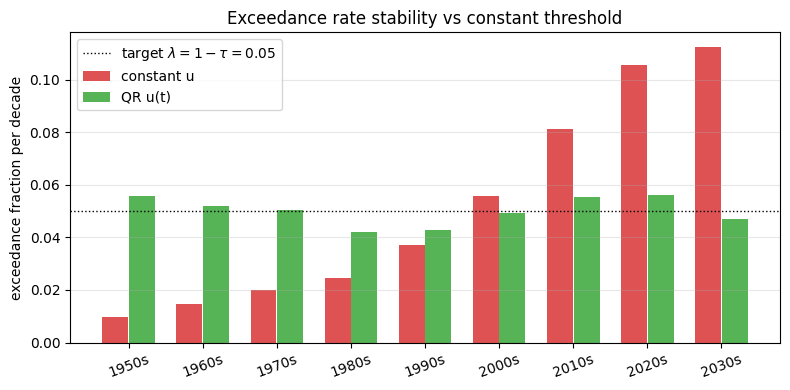

In [6]:
def per_decade_rates(series_, threshold):
    if isinstance(threshold, xr.DataArray):
        excess_indicator = (series_ > threshold).astype(float)
    else:
        excess_indicator = (series_ > threshold).astype(float)
    decadal = excess_indicator.groupby(series_.time.dt.year // 10).mean()
    return decadal


rates_const = per_decade_rates(series, u_const)
rates_qr = per_decade_rates(series, u_qr)
decade_labels = [f"{1940 + 10 * (i + 1)}s" for i in range(len(rates_const))]

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(rates_const))
ax.bar(
    x_pos - 0.18,
    rates_const.values,
    width=0.35,
    color="tab:red",
    alpha=0.8,
    label="constant u",
)
ax.bar(
    x_pos + 0.18,
    rates_qr.values,
    width=0.35,
    color="tab:green",
    alpha=0.8,
    label="QR u(t)",
)
ax.axhline(
    1 - TARGET_TAU,
    color="black",
    lw=1,
    ls=":",
    label=rf"target $\lambda = 1-\tau = {1 - TARGET_TAU:.2f}$",
)
ax.set_xticks(x_pos)
ax.set_xticklabels(decade_labels, rotation=20)
ax.set_ylabel("exceedance fraction per decade")
ax.set_title("Exceedance rate stability vs constant threshold")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Reading this.**

- The black dashed line is the target rate $1 - \tau = 0.05$.
- The red bars (constant $u$) start near zero in the early decades and climb above $0.10$ later — a **factor of 2-3** distortion that ruins the Poisson-GPD return-level formula.
- The green bars (QR $u(t)$) hug the target throughout — exactly what we want.

## 5. GPD fit on residual exceedances

With the QR threshold in hand, the GPD step is unchanged from the previous notebook, modulo computing the *residual* exceedances $y_i = z_i - u(t_i)$ at the time-varying threshold. We use `decluster_runs` for the same i.i.d. reasons as before, with the time-varying threshold passed as an `xr.DataArray`.

In [7]:
declustered = decluster_runs(series, threshold=u_qr, reduction="max")
keep = declustered.notnull()
declustered_excess = (declustered - u_qr).where(keep).dropna("time")
excess = jnp.asarray(declustered_excess.values)
event_times = declustered_excess.time.values

print(f"Declustered residual exceedances: {len(excess)}")
print(f"Empirical mean residual:          {float(excess.mean()):.3f}")
print(f"Empirical std residual:           {float(excess.std()):.3f}")


def gpd_model(excess, sigma_prior_scale):
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_prior_scale * 2))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample(
        "obs",
        GeneralizedParetoDistribution(scale=sigma, concentration=xi),
        obs=excess,
    )


sigma_loc = float(jnp.mean(excess))
kernel = NUTS(gpd_model, target_accept_prob=0.95, init_strategy=init_to_median)
mcmc = MCMC(kernel, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False)
mcmc.run(KEY, excess=excess, sigma_prior_scale=sigma_loc)
mcmc.print_summary(prob=0.95)
posterior_qr = mcmc.get_samples()

Declustered residual exceedances: 1218
Empirical mean residual:          1.702
Empirical std residual:           1.378


/tmp/ipykernel_2853712/3054351788.py:24: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=1500, num_samples=2000, num_chains=2,



                mean       std    median      2.5%     97.5%     n_eff     r_hat
     sigma      2.04      0.07      2.04      1.91      2.17   1008.14      1.00
        xi     -0.20      0.02     -0.21     -0.24     -0.17   1010.49      1.01

Number of divergences: 2


## 6. Comparison: constant-threshold GPD on the same data

What if we had used the constant threshold? We refit the GPD with $u_{\text{const}}$ and *all* exceedance days (including the late-decades flood). The mis-specified version will see a wider mix of "tail" and "bulk" values and bias the fit.

In [8]:
declustered_c = decluster_runs(series, threshold=u_const, reduction="max")
declustered_excess_c = declustered_c.dropna("time") - u_const
excess_c = jnp.asarray(declustered_excess_c.values)
print(f"Declustered exceedances (constant u): {len(excess_c)}")

sigma_loc_c = float(jnp.mean(excess_c))
kernel_c = NUTS(gpd_model, target_accept_prob=0.95, init_strategy=init_to_median)
mcmc_c = MCMC(
    kernel_c, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False
)
mcmc_c.run(KEY, excess=excess_c, sigma_prior_scale=sigma_loc_c)
posterior_const = mcmc_c.get_samples()

Declustered exceedances (constant u): 1116


/tmp/ipykernel_2853712/612406942.py:8: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_c = MCMC(kernel_c, num_warmup=1500, num_samples=2000, num_chains=2,


### Posterior comparison

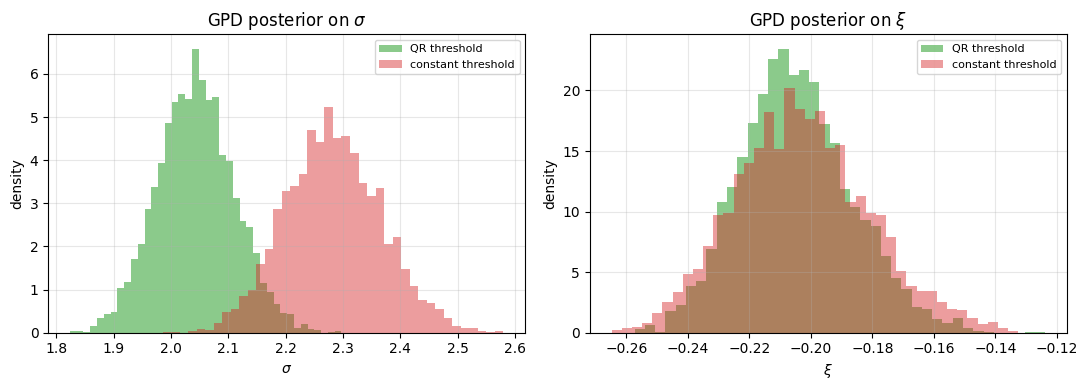

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ["sigma", "xi"], strict=True):
    ax.hist(
        np.asarray(posterior_qr[name]),
        bins=40,
        density=True,
        color="tab:green",
        alpha=0.55,
        label="QR threshold",
    )
    ax.hist(
        np.asarray(posterior_const[name]),
        bins=40,
        density=True,
        color="tab:red",
        alpha=0.45,
        label="constant threshold",
    )
    ax.set_xlabel(rf"$\{name}$")
    ax.set_ylabel("density")
    ax.set_title(rf"GPD posterior on $\{name}$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Reading this:

- **$\sigma$ is much larger** under the constant threshold, because in late decades the trend has lifted the bulk above the constant $u$, so the fit absorbs that bulk inflation into the GPD scale.
- **$\xi$** can shift toward zero or slightly positive under mis-spec, again because the mid-bulk values look like exponential noise.
- The QR-threshold posterior is the clean fit on what is *actually* the residual tail.

## 7. Time-varying return levels

With the QR threshold, the year-$T$ return level is itself time-varying:

$$
z_T(t) \;=\; u(t) + \frac{\sigma}{\xi}\Bigl[(T \lambda_u)^{\xi} - 1\Bigr], \qquad \xi \neq 0.
$$

We compute the 100-year return level *as a function of the year* by combining the QR threshold $u(t)$ with the stationary GPD posterior on $(\sigma, \xi)$.

Declustered events per year (QR): λ_u = 15.226


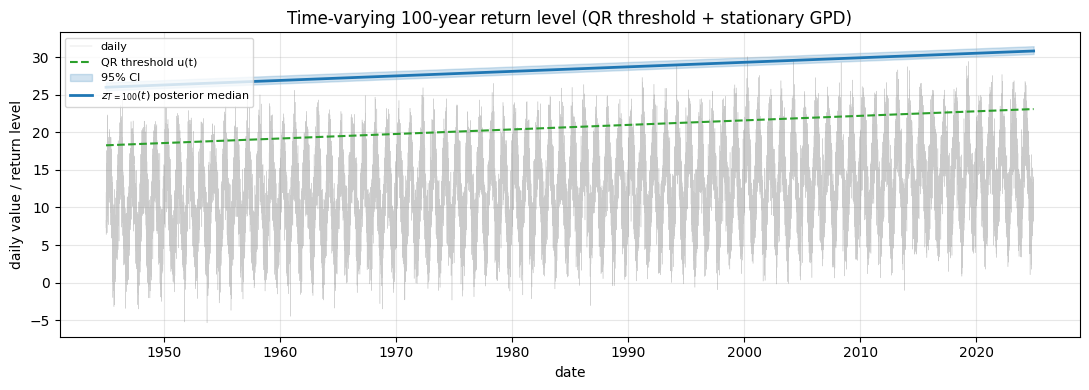

100-yr return level at start of record: 26.02
100-yr return level at end of record:   30.84
Trend in 100-yr return level:           +4.83 over 80 yr = 0.060/yr


In [10]:
years_of_data = (series.time.values[-1] - series.time.values[0]) / np.timedelta64(
    365, "D"
)
lambda_u = len(excess) / years_of_data
print(f"Declustered events per year (QR): λ_u = {lambda_u:.3f}")

T = 100.0


def rl_pot_T(sigma, xi, T_, lam):
    Tlam = T_ * lam
    safe_xi = jnp.where(jnp.abs(xi) < 1e-7, 1.0, xi)
    return jnp.where(
        jnp.abs(xi) < 1e-7,
        sigma * jnp.log(Tlam),
        (sigma / safe_xi) * (jnp.power(Tlam, safe_xi) - 1.0),
    )


excess_at_T = jax.vmap(lambda s, x: rl_pot_T(s, x, T, lambda_u))(
    posterior_qr["sigma"], posterior_qr["xi"]
)
excess_med = float(jnp.median(excess_at_T))
excess_lo = float(jnp.quantile(excess_at_T, 0.025))
excess_hi = float(jnp.quantile(excess_at_T, 0.975))

times = u_qr.time.values
zT_med = u_qr.values + excess_med
zT_lo = u_qr.values + excess_lo
zT_hi = u_qr.values + excess_hi

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.plot(series.time, series.values, lw=0.3, alpha=0.4, color="tab:gray", label="daily")
ax.plot(
    times, u_qr.values, color="tab:green", lw=1.5, ls="--", label="QR threshold u(t)"
)
ax.fill_between(times, zT_lo, zT_hi, color="tab:blue", alpha=0.2, label="95% CI")
ax.plot(
    times,
    zT_med,
    color="tab:blue",
    lw=2,
    label=rf"$z_{{T={T:.0f}}}(t)$ posterior median",
)
ax.set_xlabel("date")
ax.set_ylabel("daily value / return level")
ax.set_title("Time-varying 100-year return level (QR threshold + stationary GPD)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

z_start = float(zT_med[0])
z_end = float(zT_med[-1])
print(f"100-yr return level at start of record: {z_start:.2f}")
print(f"100-yr return level at end of record:   {z_end:.2f}")
print(
    f"Trend in 100-yr return level:           +{z_end - z_start:.2f} "
    f"over {N_YEARS} yr = {(z_end - z_start) / N_YEARS:.3f}/yr"
)

**Interpretation.**

- The 100-year return level rises in lockstep with the QR threshold. By construction, the *excess part* of the formula is stationary; the trend lives entirely in $u(t)$.
- This is a deliberately simple model: the trend is in the *location* of the tail, not its shape or scale. If the tail itself is changing — heavier tails over time, more volatile excesses — you need a non-stationary GPD, where $\sigma$ or $\xi$ are themselves time- or covariate-dependent. That is the natural sequel to this notebook (and a v0.1 polish item for `xtremax`).

## Takeaways

- **Quantile regression separates *trend* from *tail*.** Fit the trend in the threshold; fit the tail in the residual GPD. Each step does what it does best.
- **Constant thresholds break under non-stationarity.** Per-decade exceedance rates can drift by 2-3× and bias both $\sigma$ and the implied return levels.
- **The QR threshold is just an LP.** `xtremax.extraction.quantile_regression_threshold` wraps `sklearn.linear_model.QuantileRegressor` and accepts arbitrary covariates, not just time. Replace `t` with any covariate vector you care about (SST, ENSO index, AMO, …) and the recipe is unchanged.
- **Time-varying return levels emerge for free.** With a stationary residual GPD and a time-varying $u(t)$, the year-$T$ return level translates as $z_T(t) = u(t) + \text{(constant excess)}$. The slope of $z_T(t)$ is the slope of the threshold — a direct readout of the trend.
- **Limitations.** This is a *location-shift* non-stationarity model. If the *tail itself* is changing — heavier tails over time, more volatile excesses — you need a non-stationary GPD, where $\sigma$ or $\xi$ are themselves covariate-dependent. That is the natural follow-on extension.

This concludes the six-notebook tour of `xtremax`'s extreme-value distributions and extraction utilities. The closing reading list from notebook 1 (Coles 2001; Embrechts, Klüppelberg & Mikosch 1997; Beirlant, Goegebeur, Segers & Teugels 2004) is the right entry point if you want to push beyond stationarity assumptions.